# Car Price Prediction


#### Project Workflow
1. Understand the Dataset
- Review all columns and their meanings (you’ve already done this — great start!)
- Identify which variables are:
- Independent (features)
- Dependent (target)

2. Clean and Prepare the Data
- Check for missing values or anomalies (e.g., nulls sales)
- Create new features if needed:

3. Explore the Data (EDA)
Use visualizations to uncover patterns:
- 📉 Boxplots to see sales distribution by weather or promotion
- 📌 Correlation heatmap to see which features influence sales most

4. Model Sales Drivers
- Use regression models (e.g., Linear Regression, Random Forest, XGBoost) to predict daily_sales
- Evaluate feature importance: which variables drive sales the most?
- Try time series models (e.g., ARIMA, Prophet) if you're forecasting future sales

7. Present Your Work
- Create a dashboard (Excel, Power BI, or Tableau)
- Summarize key insights in a slide deck or report
- Include visuals, trends, and actionable takeaways


In [1]:
# Importing Libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [2]:
#Importing Dataset
df = pd.read_csv('car_sales_data.csv')

raw_df = df.copy()

## Data Cleaning

In [3]:
df.head()

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         50000 non-null  object 
 1   Model                50000 non-null  object 
 2   Engine size          50000 non-null  float64
 3   Fuel type            50000 non-null  object 
 4   Year of manufacture  50000 non-null  int64  
 5   Mileage              50000 non-null  int64  
 6   Price                50000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 2.7+ MB


In [5]:
df.describe()

,Engine size,Year of manufacture,Mileage,Price
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.773058,2004.209440,112497.320700,13828.903160
std,0.734108,9.645965,71632.515602,16416.681336
min,1.000000,1984.000000,630.000000,76.000000
25%,1.400000,1996.000000,54352.250000,3060.750000
50%,1.600000,2004.000000,100987.500000,7971.500000
75%,2.000000,2012.000000,158601.000000,19026.500000
max,5.000000,2022.000000,453537.000000,168081.000000


In [6]:
df.duplicated().sum()

12

In [7]:
df[df.duplicated()]

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
5426,VW,Polo,1.2,Petrol,2003,10000,8024
9862,Ford,Mondeo,1.4,Diesel,1987,224569,883
14745,BMW,Z4,2.4,Petrol,1999,12000,13410
19020,Toyota,Yaris,1.0,Petrol,1996,13500,5087
19337,VW,Polo,1.0,Petrol,2000,11500,5950
23927,VW,Polo,1.2,Petrol,2021,1000,27901
25368,VW,Golf,1.2,Diesel,2011,6000,17401
28576,VW,Polo,1.2,Petrol,2003,10000,8024
34246,VW,Passat,2.0,Diesel,2003,10000,16087
35647,Ford,Focus,1.6,Petrol,2019,2000,39636


In [8]:
# Handling Duplicates
df = df.drop_duplicates()

In [9]:
df.duplicated().sum()

0

In [10]:
df = df.reset_index(drop=True)

In [11]:
# Handling Missing Values
df.isnull().sum()

Manufacturer           0
Model                  0
Engine size            0
Fuel type              0
Year of manufacture    0
Mileage                0
Price                  0
dtype: int64

## EDA


✅ 1. Univariate Analysis (Quick Checks)
✔ Histograms / KDE plots for:
- Price
- Mileage
- Year of manufacture
- Engine size


✅ 2. Outlier Detection (Outliers can ruin models if not handled.)
Use: Boxplots, IQR, Scatterplots of Price vs key features
Look specifically for:
- Extremely old cars
- Very high mileage cars
- Price values too low or too high compared to the rest


✅ 3. Relationship Analysis (Minimal Pairwise Checks)
Only 3 scatterplots are needed:
- Price vs Mileage (declining trend?)
- Price vs Age/Year (strong expected relationship)
- Price vs Engine size (positive relationship)
Purpose:
Helps you see whether linear or non-linear models might work better, and where transformations may help.


✅ 4. Categorical Variable Insights
✔ View counts of: Manufacturer, Model, Fuel type
`df['Manufacturer'].value_counts()`
`df['Model'].value_counts()`
`df['Fuel type'].value_counts()`

Why this matters:
- Helps detect rare categories
- Helps decide which encoding to use
- Model will likely need target/frequency encoding
- Manufacturer/Fuel type → one-hot is fine


✅ 5. Multicollinearity Check (Optional but Recommended)

Mainly to avoid redundant variables:

- Year vs Car age (if you eventually create it)
- Engine size vs Engine category
- Mileage vs Mileage per year (after engineering)

For now, just check correlation among numerical columns


`NB: Do No7 after Completing Data Preprocessing and Feature Engineering`

### Univariate Analysis; To detect outliers and Skeweness
✔ Histograms / KDE and boxplots for:
- Price
- Mileage
- Year of manufacture
- Engine size

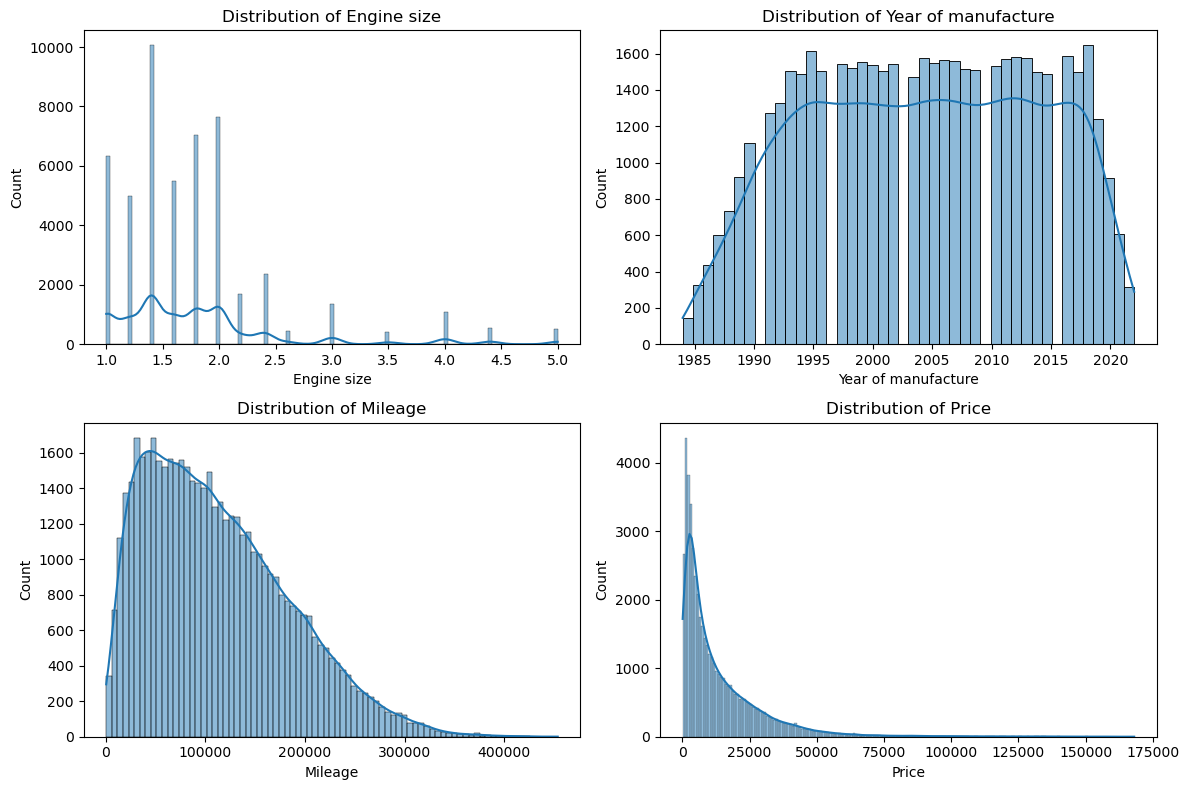

In [12]:
# Visualizing Histogram + KDE for numerical columns
numerical_features = ['Engine size', 'Year of manufacture', 'Mileage', 'Price']

plt.figure(figsize=(12, 8))

for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

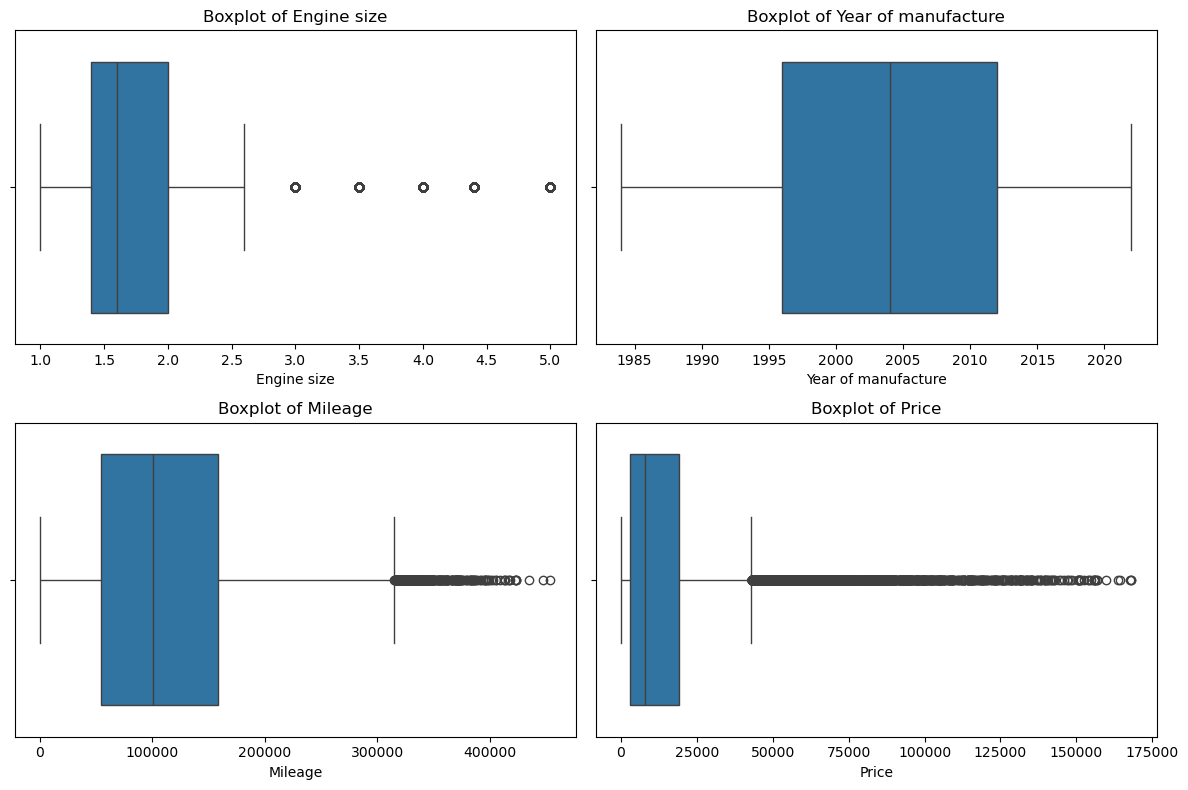

In [13]:
# Visualizing boxplots for numerical columns
numerical_features = ['Engine size', 'Year of manufacture', 'Mileage', 'Price']

plt.figure(figsize=(12, 8))

for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[feature])
    plt.title(f'Boxplot of {feature}')

plt.tight_layout()
plt.show()


In [14]:
df[numerical_features].describe()

,Engine size,Year of manufacture,Mileage,Price
count,49988.000000,49988.000000,49988.000000,49988.000000
mean,1.773140,2004.209630,112515.561215,13829.112387
std,0.734149,9.646056,71624.341062,16417.812203
min,1.000000,1984.000000,630.000000,76.000000
25%,1.400000,1996.000000,54375.250000,3059.750000
50%,1.600000,2004.000000,101011.500000,7971.000000
75%,2.000000,2012.000000,158617.250000,19028.500000
max,5.000000,2022.000000,453537.000000,168081.000000


### Looking for Correlations

In [15]:
df.dtypes

Manufacturer            object
Model                   object
Engine size            float64
Fuel type               object
Year of manufacture      int64
Mileage                  int64
Price                    int64
dtype: object

In [16]:
corr_matrix = df[numerical_features].corr()

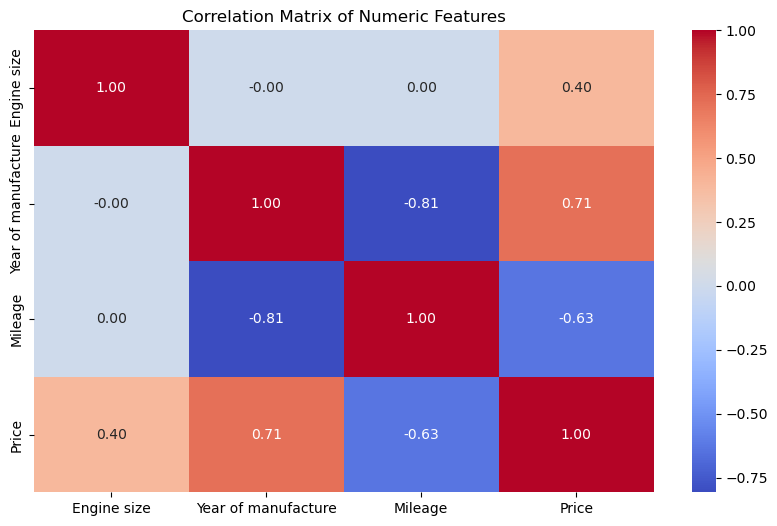

In [17]:
# Visualizing the correlation matrix using a heatmap

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Features')
plt.show()

From the correlation matrix above;
- Year of manufacture has a strong direct proportionality to Price
- Engine size is moderately directly proportional to price
- Mileage is Strongly Indirectly Proportional to the Price

In [18]:
df.head(10)

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101
5,Ford,Focus,1.4,Petrol,2018,33603,29204
6,Ford,Mondeo,1.8,Diesel,2010,86686,14350
7,Toyota,Prius,1.4,Hybrid,2015,30663,30297
8,VW,Polo,1.2,Petrol,2012,73470,9977
9,Ford,Focus,2.0,Diesel,1992,262514,1049


### Relationship / Multivariate Analysis


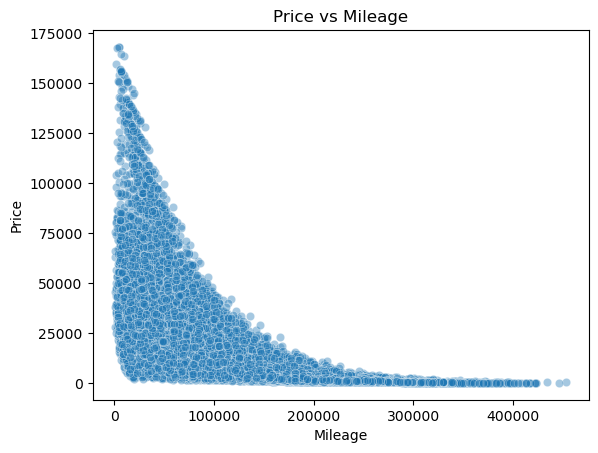

In [19]:
#Price vs Mileage Scatter Plot
sns.scatterplot(data=df, x="Mileage", y="Price", alpha=0.4)
plt.title('Price vs Mileage')
plt.show()

`Theres a downward trend i.e; the lower the milage the higher the price.`

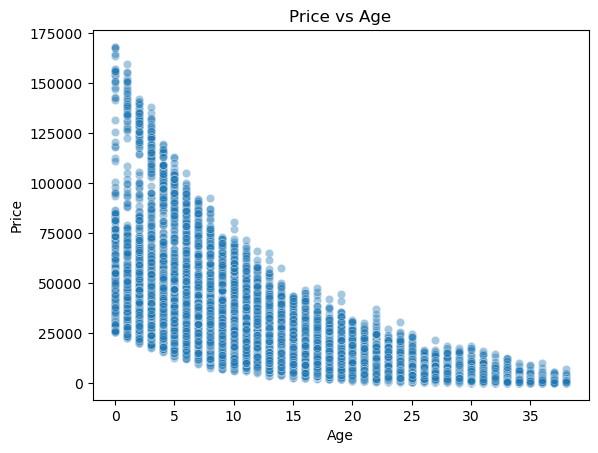

In [20]:
#Price vs Age Scatter Plot
#First create a new column 'Age' because Year of manufacture is not very intuitive
df['Age'] = 2022 - df['Year of manufacture'] #Assuming the current year is 2022


sns.scatterplot(data=df, x="Age", y="Price", alpha=0.4)
plt.title('Price vs Age')
plt.show()

`Theres a downward trend as well in the price vs Age i.e; the lower the older the age, lower the price.`

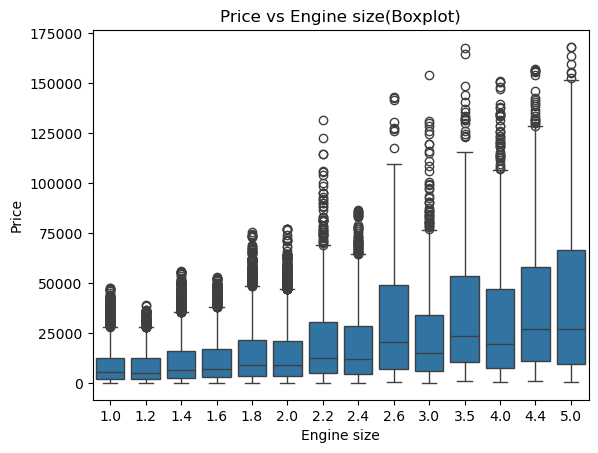

In [21]:
# Boxplot for Price vs Engine size
sns.boxplot(data=df, x="Engine size", y="Price")
plt.title("Price vs Engine size(Boxplot)")
plt.show()

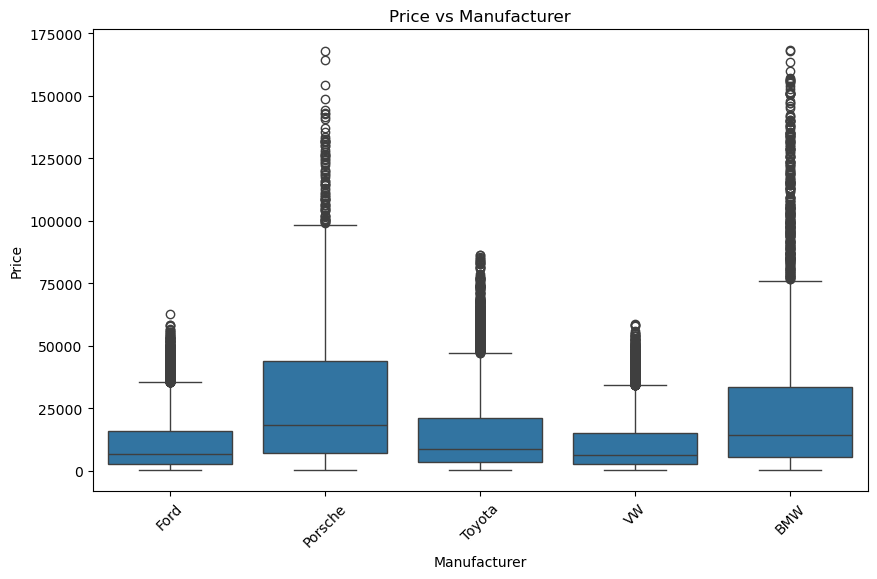

In [22]:
# Price vs Manufacturer Boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Manufacturer", y="Price")
plt.xticks(rotation=45)
plt.title("Price vs Manufacturer")
plt.show()

`In order of price: Porsche > BMW > Toyota > Ford > VW`

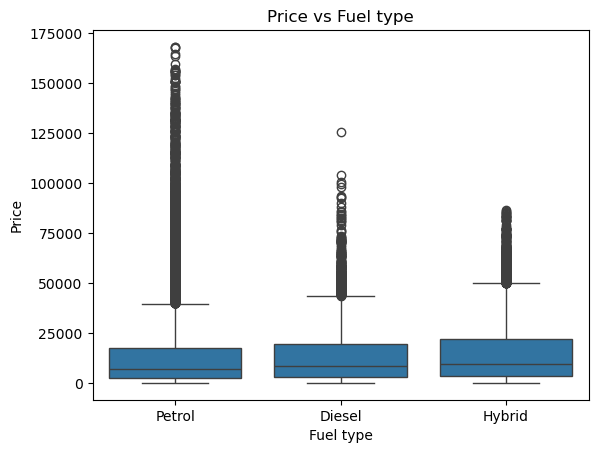

In [23]:
#Price vs Fuel type
sns.boxplot(data=df, x="Fuel type", y="Price")
plt.title("Price vs Fuel type")
plt.show()

`In order of price: Hybrid > Diesel > Petrol`

### Categorical Variable Insights
✔ View counts of: Manufacturer, Model, Fuel type
`df['Manufacturer'].value_counts()`
`df['Model'].value_counts()`
`df['Fuel type'].value_counts()`

Why this matters:
- Helps detect rare categories
- Helps decide which encoding to use
- Model will likely need target/frequency encoding
- Manufacturer/Fuel type → one-hot is fine

In [24]:
df['Manufacturer'].value_counts()


Manufacturer
Ford       14956
VW         14906
Toyota     12553
BMW         4964
Porsche     2609
Name: count, dtype: int64

In [25]:
print(df['Model'].value_counts())

Model
Mondeo        5057
Golf          5049
Polo          4988
Focus         4975
Fiesta        4924
Passat        4869
RAV4          4292
Prius         4171
Yaris         4090
Z4            1687
M5            1645
X3            1632
911            872
Cayenne        870
718 Cayman     867
Name: count, dtype: int64


In [26]:
df['Model'].unique()

array(['Fiesta', '718 Cayman', 'Mondeo', 'RAV4', 'Polo', 'Focus', 'Prius',
       'Golf', 'Z4', 'Yaris', '911', 'Passat', 'M5', 'Cayenne', 'X3'],
      dtype=object)

In [27]:

df['Fuel type'].value_counts()

Fuel type
Petrol    25480
Diesel    13264
Hybrid    11244
Name: count, dtype: int64

`NB: When performing encoding on the categorical colums in the Preprocessing steps;`

Manufacturer and Fuel type --> One-hot encoding 

Model --> Target encoding

`Also, Perform the Target encoding on the training set alone rather than on the whole daset so as to avoid feature leakage`

# Data Preprocessing

✅ 1. Essential Feature Engineering for Car Price Prediction

- Car Age (instead of using Year directly)
`df['Car_Age'] = current_year - df['Year of manufacture']`

- Mileage per Year (Usage Intensity). i.e A car with 150,000 km over 15 years is not the same as 150,000 km over 5 years.
`df['Mileage_per_Year'] = df['Mileage'] / df['Car_Age'].replace(0, 1)`

- Engine Size Category (optional binning)
You can create bins like:
Small: <1.4
Medium: 1.4–2.0
Large: >2.0
Or just standard binning:
`df['Engine_Category'] = pd.cut(df['Engine size'], bins=[0, 1.4, 2.0, 4.0], labels=['Small','Medium','Large'])`

- Log-transform the target (Price): Car prices are usually right-skewed. Applying log transformation stabilizes variance and reduces outlier impact
`df['Log_Price'] = np.log(df['Price'])`


✅ 2. Encoding Categorical Variables Properly
Thefore the ffg encoding is prefarable;
Manufacturer → One-hot encoding is fine.
Fuel Type → One-hot encoding works.
Model → This is tricky.


✅ 3. Interaction features (often useful)
Useful examples:
Engine size × Manufacturer
Engine size × Fuel type
Car age × Mileage

✅ 4. Remove or treat extreme outliers.
Before fitting the model:
-Remove cars priced at absurdly low or high values
- Remove mileage above the 99th percentile
- Remove cars older than 30 years if they skew the model

eg: Your dataset has a 1988 Toyota — that’s essentially a classic/vintage category and will distort the model.

## Feature Engineering
- Age
- Mileage per year
- Brand popularity

In [28]:
# We've donr the feature engineering for 'Age' column already in the EDA section
print(df['Age'])

0        20
1         6
2         8
3        34
4        16
         ..
49983     4
49984    19
49985     0
49986     6
49987    10
Name: Age, Length: 49988, dtype: int64


In [29]:
df['Mileage']

0        127300
1         57850
2         39190
3        210814
4        127869
          ...  
49983     28664
49984    105120
49985      4030
49986     26468
49987    109300
Name: Mileage, Length: 49988, dtype: int64

In [30]:
df['Mileage_per_year'] = df['Mileage'] / df['Age'].replace(0,1)
print(df['Mileage_per_year'])

0         6365.000000
1         9641.666667
2         4898.750000
3         6200.411765
4         7991.812500
             ...     
49983     7166.000000
49984     5532.631579
49985     4030.000000
49986     4411.333333
49987    10930.000000
Name: Mileage_per_year, Length: 49988, dtype: float64


In [31]:
brand_freq = df['Manufacturer'].value_counts(normalize=True)
df['Brand_popularity'] = df['Manufacturer'].map(brand_freq)


In [32]:
df['Brand_popularity']

0        0.299192
1        0.052193
2        0.299192
3        0.251120
4        0.298192
           ...   
49983    0.099304
49984    0.251120
49985    0.299192
49986    0.299192
49987    0.298192
Name: Brand_popularity, Length: 49988, dtype: float64

In [33]:
# Handling Missing Values
df.isna().sum()


Manufacturer           0
Model                  0
Engine size            0
Fuel type              0
Year of manufacture    0
Mileage                0
Price                  0
Age                    0
Mileage_per_year       0
Brand_popularity       0
dtype: int64

## Encoding Categorical Variables
- Manufacturer
- Fuel type
- Model (Target encoding to be done after splitting the dataset)

In [34]:
print(df['Manufacturer'].nunique())

print(df['Manufacturer'].unique())

5
['Ford' 'Porsche' 'Toyota' 'VW' 'BMW']


In [35]:
print(df['Model'].nunique())

print(df['Model'].unique())

15
['Fiesta' '718 Cayman' 'Mondeo' 'RAV4' 'Polo' 'Focus' 'Prius' 'Golf' 'Z4'
 'Yaris' '911' 'Passat' 'M5' 'Cayenne' 'X3']


In [36]:
print(df['Fuel type'].nunique())

print(df['Fuel type'].unique())

3
['Petrol' 'Diesel' 'Hybrid']


In [37]:
df.columns

Index(['Manufacturer', 'Model', 'Engine size', 'Fuel type',
       'Year of manufacture', 'Mileage', 'Price', 'Age', 'Mileage_per_year',
       'Brand_popularity'],
      dtype='object')

In [38]:
# One-hot encoding for Manufacturer and Fuel type

cols_to_encode = ['Manufacturer', 'Fuel type']

# Creating Dummy Variables for manufacturer and fuel type
df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)


In [39]:
df.columns

Index(['Model', 'Engine size', 'Year of manufacture', 'Mileage', 'Price',
       'Age', 'Mileage_per_year', 'Brand_popularity', 'Manufacturer_Ford',
       'Manufacturer_Porsche', 'Manufacturer_Toyota', 'Manufacturer_VW',
       'Fuel type_Hybrid', 'Fuel type_Petrol'],
      dtype='object')

In [40]:
df

,Model,Engine size,Year of manufacture,Mileage,Price,Age,Mileage_per_year,Brand_popularity,Manufacturer_Ford,Manufacturer_Porsche,Manufacturer_Toyota,Manufacturer_VW,Fuel type_Hybrid,Fuel type_Petrol
0,Fiesta,1.0,2002,127300,3074,20,6365.000000,0.299192,True,False,False,False,False,True
1,718 Cayman,4.0,2016,57850,49704,6,9641.666667,0.052193,False,True,False,False,False,True
2,Mondeo,1.6,2014,39190,24072,8,4898.750000,0.299192,True,False,False,False,False,False
3,RAV4,1.8,1988,210814,1705,34,6200.411765,0.251120,False,False,True,False,True,False
4,Polo,1.0,2006,127869,4101,16,7991.812500,0.298192,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49983,M5,5.0,2018,28664,113006,4,7166.000000,0.099304,False,False,False,False,False,True
49984,Prius,1.8,2003,105120,9430,19,5532.631579,0.251120,False,False,True,False,True,False
49985,Mondeo,1.6,2022,4030,49852,0,4030.000000,0.299192,True,False,False,False,False,False
49986,Focus,1.0,2016,26468,23630,6,4411.333333,0.299192,True,False,False,False,False,False


### Transformation of numerical features
🔵 If the feature is moderately right-skewed → use Log Transformation
Use log when:

Values are positive only (no zeros, no negatives)

The tail is long but not extreme

Examples in your dataset:
✔ Price
✔ Mileage


🟢 If the feature is highly right-skewed → use Square Root or Cube Root

Use this when log is still not enough OR when there are many small values.

Works well for:
✔ Engine Size (mild skew but discrete peaks)
✔ Mileage (if log still leaves skew)


`NB After applying transformation, replot the histogram + KDE and boxplot to check if the features are still skewed. Also, remember that XGBoost model does not require transformation` 

In [41]:
# Log Transformation of the mildely skewed numerical features
df['Price_log'] = np.log1p(df['Price'])
df['Mileage_log'] = np.log1p(df['Mileage'])
df['Mileage_per_year_log'] = np.log1p(df['Mileage_per_year'])


#--------------------------
#sqrt or cube root transformation 
df['Mileage_sqrt'] = np.sqrt(df['Mileage'])


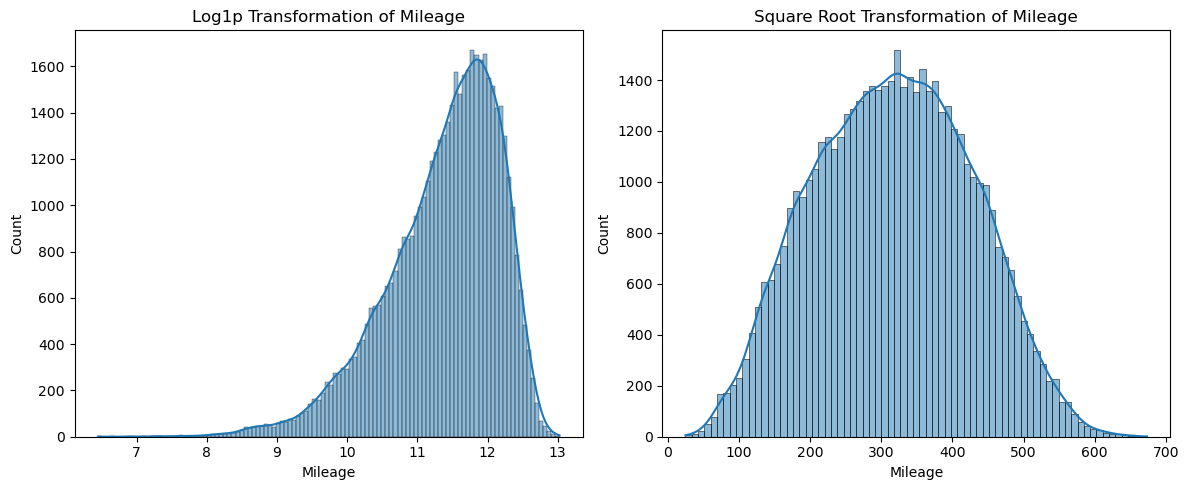

In [42]:
# Plotting log and sqrt transformations of Mileage for comparison
plt.figure(figsize=(12, 5))

# Log transformation
plt.subplot(1, 2, 1)
sns.histplot(np.log1p(df['Mileage']), kde=True)
plt.title('Log1p Transformation of Mileage')

# Square root transformation
plt.subplot(1, 2, 2)
sns.histplot(np.sqrt(df['Mileage']), kde=True)
plt.title('Square Root Transformation of Mileage')

plt.tight_layout()
plt.show()

In [43]:
df.columns

Index(['Model', 'Engine size', 'Year of manufacture', 'Mileage', 'Price',
       'Age', 'Mileage_per_year', 'Brand_popularity', 'Manufacturer_Ford',
       'Manufacturer_Porsche', 'Manufacturer_Toyota', 'Manufacturer_VW',
       'Fuel type_Hybrid', 'Fuel type_Petrol', 'Price_log', 'Mileage_log',
       'Mileage_per_year_log', 'Mileage_sqrt'],
      dtype='object')

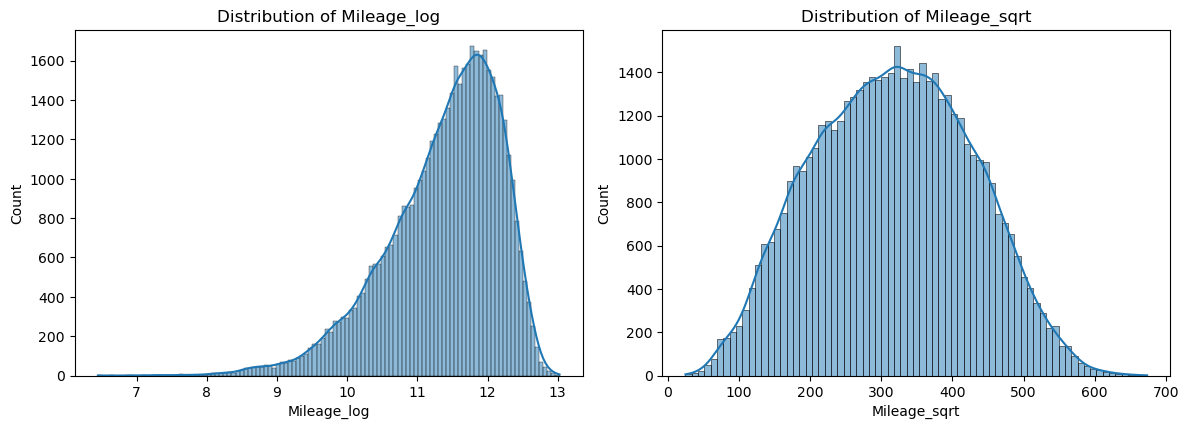

In [44]:
# Visualizing Histogram + KDE for numerical columns
transformed_features = ['Mileage_log', 'Mileage_sqrt']

plt.figure(figsize=(12, 8))

for i, feature in enumerate(transformed_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

Based on the plots:

- `Mileage_log:` The log-transformed distribution is much closer to normal (bell-shaped), with reduced skewness and a more symmetric appearance.
- `Mileage_sqrt:` The square root transformation also improves the distribution, but it is still more peaked and less symmetric than the log transformation.
`NB:`
The log transformation (Mileage_log) is the better choice for your Mileage variable. It produces a distribution that is more suitable for most regression and statistical modeling tasks, especially when using linear models.

Therefore, Keep and use the Mileage_log feature for your modeling. You can drop or ignore the Mileage_sqrt column.

# Train / Test Split

We spliting the dataset into 3 (training set, test(or validation) set and app(To be used on the streamlit app))

In [47]:
#Separating Features and Target Variable

X = df.drop(columns=['Price_log', 'Price']) #Features
y = df[['Price_log', 'Price']] #Target

In [48]:
y

,Price_log,Price
0,8.031060,3074
1,10.813861,49704
2,10.088846,24072
3,7.441907,1705
4,8.319230,4101
...,...,...
49983,11.635205,113006
49984,9.151757,9430
49985,10.816834,49852
49986,10.070315,23630


In [49]:
# 1st split: Hold-out set (never touched until the end)

from sklearn.model_selection import train_test_split

# First split: Hold-out set (never touched until the end)
X_temp, X_app, y_temp, y_app = train_test_split(
    X, y, test_size=0.15, random_state=42
)


In [50]:
# 2nd split: Training and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42
)



### Multicollinearity Check (To be done after the Preprocessing step)

Mainly to avoid redundant variables:

- Year vs Car age (if you eventually create it)
- Engine size vs Engine category
- Mileage vs Mileage per year (after engineering)

For now, just check correlation among numerical columns

In [51]:
num_features = X_train.select_dtypes(include='number')


In [52]:
print(num_features.columns)

Index(['Engine size', 'Year of manufacture', 'Mileage', 'Age',
       'Mileage_per_year', 'Brand_popularity', 'Mileage_log',
       'Mileage_per_year_log', 'Mileage_sqrt'],
      dtype='object')


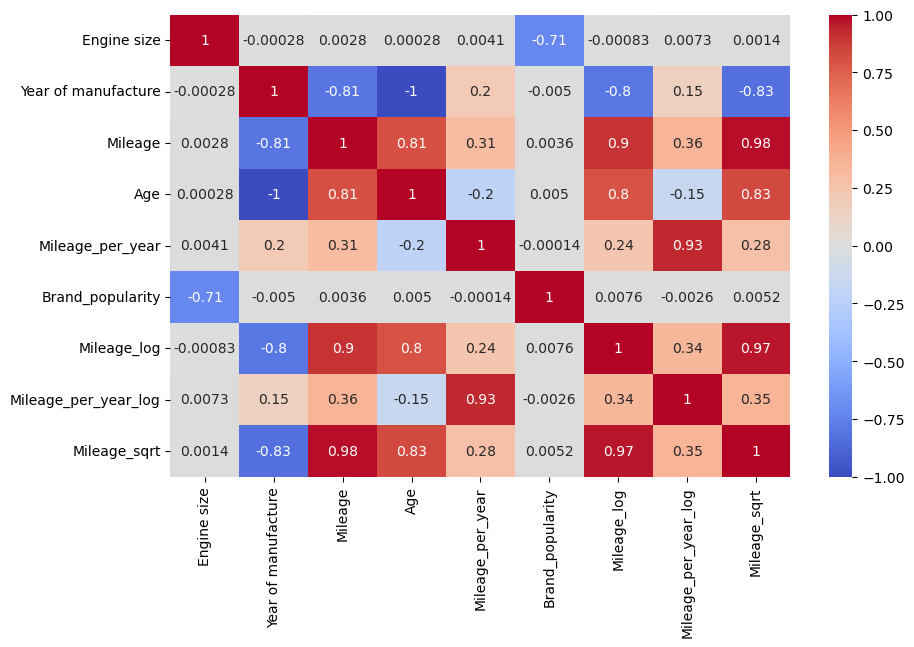

In [53]:
# Visualizing the correlation matrix using a heatmap

plt.figure(figsize=(10, 6))
sns.heatmap(num_features.corr(), annot=True, cmap='coolwarm')
plt.show()


In [54]:
print(X_train.dtypes)

Model                    object
Engine size             float64
Year of manufacture       int64
Mileage                   int64
Age                       int64
Mileage_per_year        float64
Brand_popularity        float64
Manufacturer_Ford          bool
Manufacturer_Porsche       bool
Manufacturer_Toyota        bool
Manufacturer_VW            bool
Fuel type_Hybrid           bool
Fuel type_Petrol           bool
Mileage_log             float64
Mileage_per_year_log    float64
Mileage_sqrt            float64
dtype: object


In [55]:
# ===== Branch for pipeline-based training =====
X_train_pipe = X_train.copy()
X_train_pipe = X_train_pipe.drop(columns=['Year of manufacture', 'Mileage_log', 'Mileage_sqrt', 'Mileage_per_year', 'Mileage_per_year_log'])
y_train_pipe = y_train.copy()
y_train_pipe = y_train_pipe.drop(columns=['Price_log'])


X_test_pipe = X_test.copy()
X_test_pipe = X_test_pipe.drop(columns=['Year of manufacture', 'Mileage_log', 'Mileage_sqrt', 'Mileage_per_year', 'Mileage_per_year_log'])
y_test_pipe = y_test.copy()
y_test_pipe = y_test_pipe.drop(columns=['Price_log'])

In [56]:
# Droping Redundant Columns

X_train = X_train.drop(columns=['Year of manufacture', 'Mileage', 'Mileage_sqrt', 'Mileage_per_year', 'Mileage_per_year_log'])


y_train = y_train.drop(columns=['Price'])

In [57]:
# apply same drop to test/validation set and application set
X_test = X_test.drop(columns=['Year of manufacture', 'Mileage', 'Mileage_sqrt', 'Mileage_per_year', 'Mileage_per_year_log'])
y_test = y_test.drop(columns=['Price'])

# Drop Mileage_log cos it won't be needed for the input during deployment 
X_app = X_app.drop(columns=['Year of manufacture', 'Mileage_log', 'Mileage_sqrt', 'Mileage_per_year', 'Mileage_per_year_log'])
y_app = y_app.drop(columns=['Price_log'])

In [58]:
# Saving the application test set to CSV files
app_test_features_df = X_app.copy()
app_test_target_df = y_app.copy()


app_test_features_df.to_csv('app_test_features.csv', index=False)
app_test_target_df.to_csv('app_test_target.csv', index=False)


### Variance Inflation Factor (VIF) — the real check

In [59]:
num_features = X_train.select_dtypes(include='number')


In [60]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = num_features.columns
vif_data["VIF"] = [
    variance_inflation_factor(num_features.values, i)
    for i in range(num_features.shape[1])
]

vif_data.sort_values(by="VIF", ascending=False)


,feature,VIF
3,Mileage_log,68.776387
2,Brand_popularity,22.482925
0,Engine size,12.540713
1,Age,6.226671


### Target Encoding for `Model` Column

In [61]:
import category_encoders as ce

# Initialize the target encoder for the 'Model' column
target_encoder = ce.TargetEncoder(cols=['Model'])


In [62]:
# Fit on X_train and y_train only (no leakage from X_test or app_test)
target_encoder.fit(X_train['Model'], y_train)


,verbose,0
,cols,['Model']
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,min_samples_leaf,20
,smoothing,10
,hierarchy,None


In [63]:
# Transform X_train
X_train_encoded = X_train.copy()
X_train_encoded['Model'] = target_encoder.transform(X_train['Model'])

# Transform X_test
X_test_encoded = X_test.copy()
X_test_encoded['Model'] = target_encoder.transform(X_test['Model'])


### Feature Scaling

In [64]:
numeric_features = ['Mileage_log', 'Brand_popularity', 'Engine size', 'Age', 'Model']


In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


In [66]:
# Make copies to preserve originals
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

# Fit scaler on training data numeric features
X_train_scaled[numeric_features] = scaler.fit_transform(X_train_encoded[numeric_features])

# Transform test set
X_test_scaled[numeric_features] = scaler.transform(X_test_encoded[numeric_features])


# Build the Model
- Linear Regression
- Random Forest Regression
- XGBoost



### Linear Regression Model


In [67]:
# Fit the Linear Regression Model on the Scaled Data

from sklearn.linear_model import LinearRegression  
regressor = LinearRegression()
regressor.fit(X_train_scaled, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [68]:
# Predicting the Test Set Results
y_pred = regressor.predict(X_test_scaled)

y_pred

array([[8.35271468],
       [7.56492734],
       [9.72632007],
       ...,
       [8.04013914],
       [9.29387593],
       [7.6207535 ]])

In [69]:
y_test

,Price_log
35525,8.597113
48960,7.380256
7425,9.948700
27096,9.912100
13193,9.296151
...,...
37170,9.273409
40176,9.612065
8135,8.095294
27812,9.498972


In [70]:
# Evaluating model performance

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

MAE: 0.20
RMSE: 0.28
R² Score: 0.95


In [71]:
# Convert predictions back to actual price
y_test_pred_price = np.expm1(y_pred)
y_test_actual_price = np.expm1(y_test)


In [72]:
price_mae = mean_absolute_error(y_test_actual_price, y_test_pred_price)
price_rmse = np.sqrt(mean_squared_error(y_test_actual_price, y_test_pred_price))
price_mae, price_rmse,

print(f"MAE: {price_mae:.2f}")
print(f"RMSE: {price_rmse:.2f}")

MAE: 2946.79
RMSE: 9173.60


### Random Forest Regression

In [73]:
# Fitting the Random Forest Regression Model into the Dataset
from sklearn.ensemble import RandomForestRegressor
rf_regressor = RandomForestRegressor(n_estimators=300, random_state=42)

rf_regressor.fit(X_train_encoded, y_train)


c:\Users\odebi\anaconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [74]:
rf_y_pred = rf_regressor.predict(X_test_encoded)


In [75]:
rf_y_pred

array([8.5758172 , 7.33025623, 9.94213712, ..., 8.07729169, 9.5006169 ,
       7.11119095])

In [76]:
y_test.head(10)

,Price_log
35525,8.597113
48960,7.380256
7425,9.948700
27096,9.912100
13193,9.296151
27001,10.423798
5696,9.503234
36245,6.795706
32930,8.160518
45842,9.934017


In [77]:
# Evaluating Random Forest model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


mae_rf = mean_absolute_error(y_test, rf_y_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_y_pred))
r2_rf = r2_score(y_test, y_pred)

print(f"Random Forest MAE: {mae_rf:.2f}")
print(f"Random Forest RMSE: {rmse_rf:.2f}")
print(f"Random Forest R² Score: {r2_rf:.2f}")


Random Forest MAE: 0.03
Random Forest RMSE: 0.04
Random Forest R² Score: 0.95


In [78]:
# Convert predictions back to actual price
rf_y_test_pred_price = np.expm1(rf_y_pred)
rf_y_test_actual_price = np.expm1(y_test)


In [79]:
rf_price_mae = mean_absolute_error(rf_y_test_actual_price, rf_y_test_pred_price)
rf_price_rmse = np.sqrt(mean_squared_error(rf_y_test_actual_price, rf_y_test_pred_price))
rf_price_mae, rf_price_rmse,

print(f"Random Forest MAE: {rf_price_mae:.2f}")
print(f"Random Forest RMSE: {rf_price_rmse:.2f}")

Random Forest MAE: 282.90
Random Forest RMSE: 580.32


In [80]:
# Feature Importance from Random Forest Model
import pandas as pd

feature_importance = rf_regressor.feature_importances_
features = X_train_encoded.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

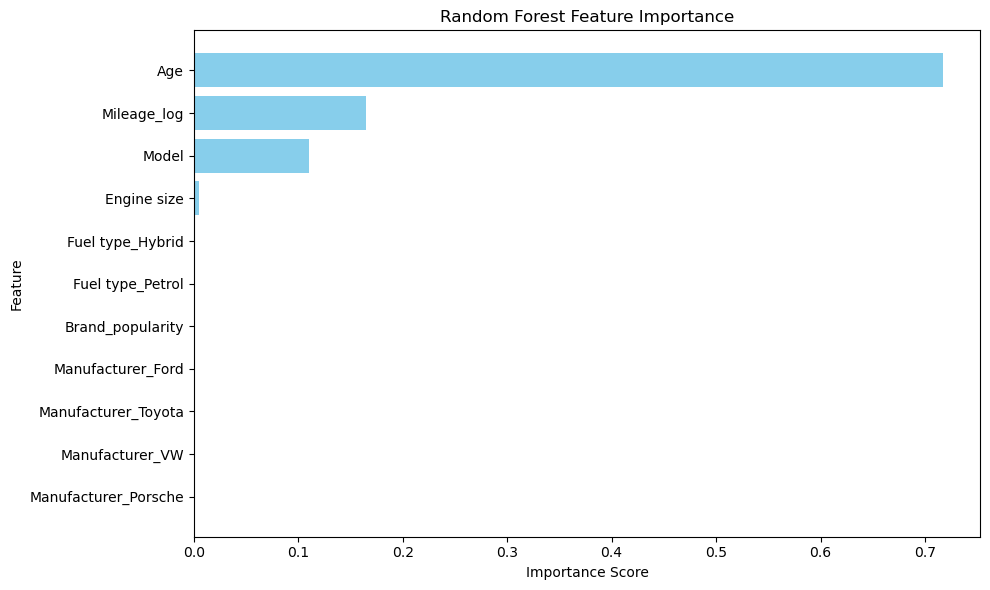

In [81]:
# Visualizing Feature Importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### XGBoost Model

In [82]:
# Fitting the XGBoost Regression Model into the Dataset using the redudced feature set
from xgboost import XGBRegressor

xgb_regressor = XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42)
xgb_regressor.fit(X_train_encoded, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [83]:
xgb_y_pred = xgb_regressor.predict(X_test_encoded)

In [84]:
xgb_y_pred

array([8.628995 , 7.3625784, 9.934683 , ..., 8.086022 , 9.501763 ,
       7.1587033], dtype=float32)

In [85]:
y_test

,Price_log
35525,8.597113
48960,7.380256
7425,9.948700
27096,9.912100
13193,9.296151
...,...
37170,9.273409
40176,9.612065
8135,8.095294
27812,9.498972


In [86]:
# Evaluating XGBoost model pexgbormance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


mae_xgb = mean_absolute_error(y_test, xgb_y_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_y_pred))
r2_xgb = r2_score(y_test, y_pred)

print(f"XGBoost MAE: {mae_xgb:.2f}")
print(f"XGBoost RMSE: {rmse_xgb:.2f}")
print(f"XGBoost R² Score: {r2_xgb:.2f}")


XGBoost MAE: 0.02
XGBoost RMSE: 0.03
XGBoost R² Score: 0.95


In [87]:
# Convert predictions back to actual price
xgb_y_test_pred_price = np.expm1(xgb_y_pred)
xgb_y_test_actual_price = np.expm1(y_test)


In [88]:
xgb_price_mae = mean_absolute_error(xgb_y_test_actual_price, xgb_y_test_pred_price)
xgb_price_rmse = np.sqrt(mean_squared_error(xgb_y_test_actual_price, xgb_y_test_pred_price))
xgb_price_mae, xgb_price_rmse,

print(f"XGBoost MAE: {xgb_price_mae:.2f}")
print(f"XGBoost RMSE: {xgb_price_rmse:.2f}")

XGBoost MAE: 169.10
XGBoost RMSE: 306.34


### Preprocessing Pipeline

In [89]:
X_train.columns

Index(['Model', 'Engine size', 'Age', 'Brand_popularity', 'Manufacturer_Ford',
       'Manufacturer_Porsche', 'Manufacturer_Toyota', 'Manufacturer_VW',
       'Fuel type_Hybrid', 'Fuel type_Petrol', 'Mileage_log'],
      dtype='object')

In [90]:
X_train_pipe.columns


Index(['Model', 'Engine size', 'Mileage', 'Age', 'Brand_popularity',
       'Manufacturer_Ford', 'Manufacturer_Porsche', 'Manufacturer_Toyota',
       'Manufacturer_VW', 'Fuel type_Hybrid', 'Fuel type_Petrol'],
      dtype='object')

In [91]:
numeric_features = [
    'Engine size',
    'Age',
    'Mileage',
    'Brand_popularity'
]

binary_features = [
    'Manufacturer_Ford',
    'Manufacturer_Porsche',
    'Manufacturer_Toyota',
    'Manufacturer_VW',
    'Fuel type_Hybrid',
    'Fuel type_Petrol'
]

categorical_features = ['Model']


In [92]:
"""
# Remove feature scaling for XGBoost: updated preprocessing pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from category_encoders import TargetEncoder
import numpy as np

def log1p_transform(x):
    return np.log1p(x)

# Numeric pipeline: only log transform Mileage
numeric_pipeline = Pipeline(steps=[
    ('mileage_log', FunctionTransformer(log1p_transform))
])

# Categorical pipeline
categorical_pipeline = Pipeline(steps=[
    ('target_encoder', TargetEncoder())
])

# Full preprocessing pipeline without feature scaling
preprocessing_pipeline = ColumnTransformer(
    transformers=[
        ('mileage', numeric_pipeline, ['Mileage']),
        ('cat', categorical_pipeline, categorical_features),
        ('num', 'passthrough', [col for col in numeric_features if col != 'Mileage']),
        ('bin', 'passthrough', binary_features)
    ]
)
"""

"\n# Remove feature scaling for XGBoost: updated preprocessing pipeline\nfrom sklearn.pipeline import Pipeline\nfrom sklearn.compose import ColumnTransformer\nfrom sklearn.preprocessing import FunctionTransformer\nfrom category_encoders import TargetEncoder\nimport numpy as np\n\ndef log1p_transform(x):\n    return np.log1p(x)\n\n# Numeric pipeline: only log transform Mileage\nnumeric_pipeline = Pipeline(steps=[\n    ('mileage_log', FunctionTransformer(log1p_transform))\n])\n\n# Categorical pipeline\ncategorical_pipeline = Pipeline(steps=[\n    ('target_encoder', TargetEncoder())\n])\n\n# Full preprocessing pipeline without feature scaling\npreprocessing_pipeline = ColumnTransformer(\n    transformers=[\n        ('mileage', numeric_pipeline, ['Mileage']),\n        ('cat', categorical_pipeline, categorical_features),\n        ('num', 'passthrough', [col for col in numeric_features if col != 'Mileage']),\n        ('bin', 'passthrough', binary_features)\n    ]\n)\n"

In [93]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from category_encoders import TargetEncoder
import numpy as np

def log1p_transform(x):
    return np.log1p(x)

# Numeric pipeline: log transform Mileage only
numeric_pipeline = Pipeline(steps=[
    ('mileage_log', FunctionTransformer(
        log1p_transform,
        feature_names_out='one-to-one'
    ))
])

# Categorical pipeline: target encoding
categorical_pipeline = Pipeline(steps=[
    ('target_encoder', TargetEncoder())
])

# Full preprocessing pipeline (XGBoost-friendly)
preprocessing_pipeline = ColumnTransformer(
    transformers=[
        ('mileage', numeric_pipeline, ['Mileage']),
        ('cat', categorical_pipeline, categorical_features),
        ('num', 'passthrough', [col for col in numeric_features if col != 'Mileage']),
        ('bin', 'passthrough', binary_features)
    ],
    remainder='drop'
)


### Finalize Model Pipeline

In [94]:
from xgboost import XGBRegressor
from sklearn.compose import TransformedTargetRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessing_pipeline),
    ('model', TransformedTargetRegressor(
        regressor=xgb_model,
        func=np.log1p,
        inverse_func=np.expm1
    ))
])



In [95]:
# Train Pipeline
model_pipeline.fit(X_train_pipe, y_train_pipe)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('mileage', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [96]:
# Predicting the Test Set Results

y_pred_pipe = model_pipeline.predict(X_test_pipe)

y_pred_pipe

array([[ 5497.037 ],
       [ 1511.6604],
       [21012.05  ],
       ...,
       [ 3260.464 ],
       [13402.385 ],
       [ 1229.8314]], dtype=float32)

In [97]:
xgb_y_pred

array([8.628995 , 7.3625784, 9.934683 , ..., 8.086022 , 9.501763 ,
       7.1587033], dtype=float32)

In [98]:
# Evaluating pipeline model performance
mae = mean_absolute_error(y_test_pipe, y_pred_pipe)
rmse = np.sqrt(mean_squared_error(y_test_pipe, y_pred_pipe))
r2 = r2_score(y_test_pipe, y_pred_pipe)


print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

MAE: 154.77
RMSE: 294.37
R² Score: 1.00


In [99]:
# Freezing the Model Pipeline and Feature List for Deployment
import joblib

bundle = {
    "pipeline": model_pipeline,
    "features": X_train.columns.tolist()
}

joblib.dump(bundle, "car_price_xgb_pipeline.pkl")


['car_price_xgb_pipeline.pkl']

### Test the pipeline on the Application dataset

In [100]:
app_df = pd.read_csv('app_test_features.csv')


In [101]:
app_df.head(10)

,Model,Engine size,Mileage,Age,Brand_popularity,Manufacturer_Ford,Manufacturer_Porsche,Manufacturer_Toyota,Manufacturer_VW,Fuel type_Hybrid,Fuel type_Petrol
0,Golf,2.0,26099,5,0.298192,False,False,False,True,False,True
1,RAV4,1.8,20171,2,0.251120,False,False,True,False,True,False
2,Focus,1.8,75867,12,0.299192,True,False,False,False,False,True
3,X3,3.0,242942,26,0.099304,False,False,False,False,False,True
4,Fiesta,1.0,205475,27,0.299192,True,False,False,False,False,True
5,Yaris,1.4,237039,25,0.251120,False,False,True,False,True,False
6,M5,4.4,28558,4,0.099304,False,False,False,False,False,True
7,Passat,1.8,181398,31,0.298192,False,False,False,True,False,False
8,Yaris,1.4,64460,10,0.251120,False,False,True,False,True,False
9,Golf,2.0,147043,24,0.298192,False,False,False,True,False,True


In [102]:
prediction = model_pipeline.predict(app_df)

prediction[:5]


array([[28502.576 ],
       [60633.25  ],
       [14945.454 ],
       [ 2240.4475],
       [ 1007.3345]], dtype=float32)